# Travelling-wave test of the 1-D Orlanski phase-velocity estimate

A **self-contained** experiment (numpy + matplotlib only — no SSWEM model) that
stress-tests the phase-speed diagnostic at the heart of the Orlanski open-boundary
condition, on a field whose true phase speed we *know exactly*.

### The field
A rigid travelling wave built from an **arbitrary base profile** $f$:
$$\phi(x,t)=f(x-u\,t),$$
so **every** point of the profile moves at the same constant speed $u$ (customisable,
may be negative). $f$ is **pluggable** — pick any of the shapes in §2 (peaked wave,
Gaussian-bump train, smooth sawtooth, sine, …) or supply your own; the default is
deliberately *not* a plain sinusoid. The general machinery also supports a superposition
$\phi=\sum_m f_m(x-u_m t)$ of components with different profiles *and* speeds (§7); the
**test uses one component**.

### The estimate (faithful to the codebase)
At an east boundary the 1-D Orlanski kernel (`OSSWEM/Neural_Net/helper/orlanski_scheme.py`,
`Orlanski_scheme_logic.md`) estimates, one point inside the boundary ($x_0$, the
"$b\!-\!1$" column):
$$\Delta\phi_t=\phi(x_0,t)-\phi(x_0,t-\Delta t),\qquad
  \Delta\phi_x=\phi(x_0,t)-\phi(x_0-\Delta x,t),$$
$$\boxed{\,r_x=-\dfrac{\Delta\phi_t}{\Delta\phi_x}\,}\quad(\text{one-sided, new time level, toward the interior}).$$

### Two quantities, two units — read this once
$r_x$ is **dimensionless**: it is the local Courant number $r_x=c\,\Delta t/\Delta x$,
*not* a velocity. To compare against the theoretical speed $u$ (a velocity) we recover
$$\boxed{\,c_{\text{est}}=r_x\,\dfrac{\Delta x}{\Delta t}
     =-\dfrac{\Delta\phi_t/\Delta t}{\Delta\phi_x/\Delta x}\,}\;\;\xrightarrow[\Delta x,\Delta t\to0]{}\;u .$$
The notebook plots **both**: the velocity $c_{\text{est}}(t)$ against $u$, and the
dimensionless $r_x(t)$ against $u\,\Delta t/\Delta x$. The interactive window (§5) lets you
**drag $\Delta x$ and $\Delta t$** and watch both time series move relative to their targets.


## 1 · Imports & configuration

In [136]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

try:                                          # interactive window is optional
    from ipywidgets import interact, FloatSlider, Dropdown
    HAVE_WIDGETS = True
except Exception as _e:
    HAVE_WIDGETS = False
    print("ipywidgets unavailable -> §5 falls back to a static sweep:", _e)

# colour-blind-safe palette (Okabe-Ito subset); recessive grid
C_EST  = "#0072B2"   # estimate  c_est(t)      (blue)
C_TRUE = "#D55E00"   # theory    u / u dt/dx   (vermillion)
C_RX   = "#009E73"   # dimensionless r_x(t)    (bluish green)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 11})


ipywidgets unavailable -> §5 falls back to a static sweep: No module named 'ipywidgets'


## 2 · The base profile $f$ and the travelling wave

Different shape of the wave $f$.

- `profile_peaked` : normalized wave

$$ P_{\text {peak }}(\xi)=\mathcal{N}\left[\exp \left(\kappa \cos \frac{2 \pi \xi}{L}\right)\right] $$

- `profile_gaussian_train` : A Periodic Gaussian train

$$ P_{\text {Gaussian }}(\xi)=\mathcal{N}\left[\exp \left(-\frac{d_L(\xi)^2}{2(0.16 L)^2}\right)\right] $$

- `profile_sawtooth` : This is a band-limited sawtooth wave 

$$ P_{\text {saw }}(\xi)=\mathcal{N}\left[\sum_{n=1}^N \frac{(-1)^{n+1}}{n} \sin \left(\frac{2 \pi n \xi}{L}\right)\right] $$

and here $N = $`n_harm`. 

- `profile_sine` : A sine function profile

$$ P_{\text {sine }}(\xi)=\sin \left(\frac{2 \pi \xi}{L}\right) $$



In [137]:
def _normalise(raw_fn, L, n=8192):
    """Fold the argument into one period (guarantees period L for ANY shape),
    then normalise to zero mean & unit peak amplitude over that period."""
    wrap = lambda xi: np.asarray(xi, float) % L          # forced period L
    s = np.linspace(0.0, L, n, endpoint=False)
    g = raw_fn(s)
    m = g.mean()
    a = np.max(np.abs(g - m)) or 1.0
    return lambda xi: (raw_fn(wrap(xi)) - m) / a


def profile_peaked(L, kappa=2.2):
    """Smooth, periodic, PEAKED wave (von-Mises-like) — the non-sinusoidal default."""
    k = 2*np.pi/L
    return _normalise(lambda xi: np.exp(kappa*np.cos(k*xi)), L)

def profile_gaussian_train(L, width_frac=0.16):
    """Periodic train of Gaussian bumps of width width_frac*L."""
    w = width_frac*L
    wrap = lambda xi: (np.asarray(xi, float) + L/2) % L - L/2
    return _normalise(lambda xi: np.exp(-0.5*(wrap(xi)/w)**2), L)

def profile_sawtooth(L, n_harm=6):
    """Band-limited (smooth) sawtooth: first n_harm Fourier harmonics."""
    k = 2*np.pi/L
    def raw(xi):
        xi = np.asarray(xi, float); out = np.zeros_like(xi)
        for n in range(1, n_harm+1):
            out += ((-1)**(n+1)/n) * np.sin(n*k*xi)
        return out
    return _normalise(raw, L)

def profile_sine(L, phase=10.0):
    k = 2*np.pi/L
    return _normalise(lambda xi: np.sin(k*np.asarray(xi, float) + phase), L)

def profile_line(L, k_slope=0.4):
    """Periodic linear ramp / sawtooth of period L (k_slope only sets orientation)."""
    wrap = lambda xi: (np.asarray(xi, float) + L/2) % L - L/2   # fold into [-L/2, L/2)
    return _normalise(lambda xi: k_slope * wrap(xi), L)



PROFILES = {"peaked": profile_peaked, "gaussian_train": profile_gaussian_train,
            "sawtooth": profile_sawtooth, "sine": profile_sine, "line" : profile_line}

def make_wave(components):
    """phi(x,t) = sum_m f_m(x - u_m t). Each component is dict(f=callable, u=speed)."""
    comps = [(c["f"], float(c["u"])) for c in components]
    def phi(x, t):
        x = np.asarray(x, dtype=float); t = np.asarray(t, dtype=float)
        out = np.zeros(np.broadcast(x, t).shape)
        for f, u in comps:
            out = out + f(x - u*t)
        return out
    return phi

def steepest_phase(f, L, n=40000):
    """Location xi in [0,L) of maximum |f'| (best-conditioned sampling point)."""
    s = np.linspace(0.0, L, n, endpoint=False)
    return float(s[np.argmax(np.abs(np.gradient(f(s), s)))])


[3-wave superposition]  sine u=+50.0 x1.0, gaussian_train u=+4.0 x1.0, sine u=-30.0 x1.0  L=500 km  tau(slowest)=34.72 h  steepest xi=454.2 km


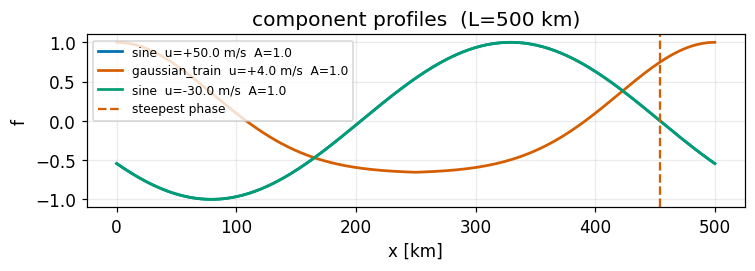

In [138]:
# ---- choose the waves (edit these) --------------------------------------------
# Each tuple: (profile_key, phase_speed_m_s, amplitude)
# One entry  ->  original single-wave behaviour (cells 6..13 unchanged).
# Two entries ->  superposition: phi(x,t) = A1 f1(x-u1 t) + A2 f2(x-u2 t).
WAVE_SPECS = [
    ("sine",  50.0,  1.0),
    ("gaussian_train",  4.0,  1.0),   # un-comment to add a second wave
    ("sine", -30.0, 1.0)
]

L = 500.0e3           # characteristic length (applied to ALL profiles) [m]

# ---- build the mode list for make_wave -------------------------------------
def _scaled_profile(name, amp):
    """Return f(xi) = amp * PROFILES[name](L)(xi), with amp in closure."""
    f_base = PROFILES[name](L)
    return lambda xi: amp * f_base(xi)

MODES = [dict(f=_scaled_profile(name, amp), u=float(u))
         for name, u, amp in WAVE_SPECS]

# backward-compatible aliases so cells 6, 8, 11, 13 work unchanged
PROFILE_NAME = WAVE_SPECS[0][0]          # first wave's profile (plot titles)
U_TRUE       = WAVE_SPECS[0][1]          # first wave's speed   (theory line, CFL)
f            = PROFILES[PROFILE_NAME](L) # first wave's profile  (steepest-phase, shape)

phi      = make_wave(MODES)
TAU      = L / min(abs(u) for _, u, _ in WAVE_SPECS)   # slowest wave sets timescale
XI_STEEP = steepest_phase(f, L)

# ---- report -----------------------------------------------------------------
spec_str = ", ".join(f"{name} u={u:+.1f} x{amp:.1f}" for name, u, amp in WAVE_SPECS)
nw = len(WAVE_SPECS)
print(f"[{'1-wave' if nw==1 else f'{nw}-wave superposition'}]  {spec_str}  "
      f"L={L/1e3:.0f} km  tau(slowest)={TAU/3600:.2f} h  "
      f"steepest xi={XI_STEEP/1e3:.1f} km")

# quick look at ALL component profiles (one curve per wave)
xs = np.linspace(0, L, 400)
fig, ax = plt.subplots(figsize=(7, 2.6))
colors = [C_EST, C_TRUE, C_RX, "#CC79A7", "#111111"]
for k, (name, u, amp) in enumerate(WAVE_SPECS):
    fk = PROFILES[name](L)
    ax.plot(xs/1e3, amp * fk(xs), color=colors[k % len(colors)], lw=1.8,
            label=f"{name}  u={u:+.1f} m/s  A={amp:.1f}")
ax.axvline(XI_STEEP/1e3, color=C_TRUE, ls="--", lw=1.5, label="steepest phase")
ax.set_xlabel("x [km]"); ax.set_ylabel("f")
ax.set_title(f"component profile{'s' if nw>1 else ''}  (L={L/1e3:.0f} km)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()


In [139]:
from matplotlib import animation
from IPython.display import HTML

N_L      = 4          # number of length scales L shown across the domain
N_TAU    = 0.5        # how many characteristic times τ to animate
n_frames = 100         # frames (each embedded in the notebook via to_jshtml)

x_anim = np.linspace(0.0, N_L*L, 600)
t_anim = np.linspace(0.0, N_TAU*TAU, n_frames)

# fixed y-limits across the whole animation
samp = np.array([phi(x_anim, tk) for tk in t_anim])
ymin, ymax = float(samp.min()), float(samp.max())
pad = 0.12*(ymax - ymin + 1e-9)

# phase of one crest of the base profile, so we can track it as it moves
xs_L     = np.linspace(0.0, L, 2000)
xi_crest = float(xs_L[np.argmax(f(xs_L))])

fig, ax = plt.subplots(figsize=(9.2, 3.2))
(line,)  = ax.plot(x_anim/1e3, phi(x_anim, 0.0), color=C_EST, lw=2)
(crest,) = ax.plot([xi_crest/1e3], [phi(np.array([xi_crest]), 0.0)[0]], "o",
                   color=C_TRUE, ms=9, label="a crest (rides at speed u)")
ax.axvline(250, color="#111111", ls="--", lw=2.0, zorder=5,
           label=r"sampling point $x_0$")
ax.annotate(r"$x_0$", xy=(250, 0), xytext=(0, -6),
            textcoords="offset points", ha="center", va="top",
            color="#111111", fontweight="bold", zorder=6)
ax.set_xlim(0, N_L*L/1e3); ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel("x [km]"); ax.set_ylabel(r"$\phi(x,t)$")
arrow_dir = 1 if U_TRUE >= 0 else -1
ax.text(0.44, 0.03, f"propagation  (u = {U_TRUE:+.1f} m/s)", transform=ax.transAxes,
        color=C_TRUE, ha="center")
title = ax.set_title("")
ax.legend(loc="upper right", framealpha=0.9)

def _update(k):
    tk = t_anim[k]
    line.set_ydata(phi(x_anim, tk))
    xc = xi_crest + U_TRUE*tk                      # crest position x_c(t) = xi_crest + u t
    crest.set_data([xc/1e3], [phi(np.array([xc]), tk)[0]])
    title.set_text(f"$\\phi(x,t)=f(x-ut)$   [{PROFILE_NAME}]   "
                   f"t = {tk/TAU:.2f} τ  ({tk/3600:.1f} h)")
    return line, crest, title

anim = animation.FuncAnimation(fig, _update, frames=n_frames, interval=80, blit=False)

# save the animation
SAVE_ANIM = True
if SAVE_ANIM:
    anim.save("traveling_wave.gif", writer="pillow", fps=12)
    print("saved: traveling_wave.gif")
plt.close(fig)                                     # avoid a duplicate static frame
HTML(anim.to_jshtml())


saved: traveling_wave.gif


# Configuration

Here defined the time step and spatial step. 

- `DX0` is the defualt spatial step. $L$ here is the length of the wave profile
-`DT0` is the defualt time step. $\tau$ here is the $L / u$ where $u$ is the wave speed.

In [140]:
DX0 = 10000
print(DX0)
DT0 = TAU / 10000.0
print(DT0)

# Courant number(s) -- one per wave component
print("CFL per mode:", {name: f"{u*DT0/DX0:.3f}" for name, u, _ in WAVE_SPECS})


10000
12.5
CFL per mode: {'sine': '-0.037', 'gaussian_train': '0.005'}


## 3 · The 1-D Orlanski estimator

the `orlanski_scheme` estimate the phase velocity based on the formula 

$$ r_x = -\frac{\Delta_t \phi}{\Delta_x \phi} $$

Here 

$$ \Delta_t \phi = \phi_k^n - \phi_k^{n-1} \qquad \Delta_x \phi = \phi_k^{n+1} - \phi_{k-1}^{n} $$

In [141]:
def orlanski_estimate(phi, x0, t, dx, dt, eps_frac=0.0):
    """1-D Orlanski estimate at position x0, time(s) t, on grid (dx, dt).

    East-boundary stencil (x0 = interior 'b-1', x0-dx = 'b-2'):
        dphi_t = phi(x0, t)     - phi(x0, t - dt)     # backward in time
        dphi_x = phi(x0, t)     - phi(x0 - dx, t)     # one-sided -> interior
        rx     = -dphi_t / dphi_x                     # Courant number
        c_est  =  rx * dx / dt                        # recovered velocity
    Samples where |dphi_x| <= eps_frac*max|dphi_x| are masked to NaN. Returns (rx, c_est).
    """
    t = np.asarray(t, dtype=float)
    dphi_t = phi(x0, t)      - phi(x0, t - dt)
    dphi_x = phi(x0, t)      - phi(x0 - dx, t)      # [O2] NEW time level, kernel convention (_orlanski_east: dphi_x = pim1 - pim2 @ n+1); was t-dt, contradicting the docstring
    absx   = np.abs(dphi_x)
    scale  = np.nanmax(absx) if absx.size else 0.0
    good   = absx > eps_frac * scale
    denom  = np.where(good, dphi_x, np.nan)
    rx     = -dphi_t / denom
    c_est  = rx * dx / dt
    return rx, c_est

def orlanski_estimate_2nd(phi, x0, t, dx, dt, eps_frac = 0.0):
    " This is the second order scheme"
    # [O2] NOTE: in this 1-D ratio the factor 2 of (3f0-4f-1+f-2) = 2*Delta*f' cancels
    # [O2] between numerator and denominator, so no /2 is needed HERE.  The deployed 2-D
    # [O2] port (Remove_periodicity_2D_NS_orlanski._orlanski_east, obc_order=2) DOES divide
    # [O2] both differences by 2, because its denominator mixes dphi_x^2 with a 1st-order
    # [O2] dphi_y^2 and the unscaled form would silently rescale eps_denom/r_max.
    dphi_t = 3 * phi(x0, t) - 4 * phi(x0, t - dt) + phi(x0, t - 2 * dt)
    dphi_x = 3 * phi(x0, t) - 4 * phi(x0 - dx, t) + phi(x0 - 2 * dx, t)
    absx   = np.abs(dphi_x)
    scale  = np.nanmax(absx) if absx.size else 0.0
    good   = absx > eps_frac * scale
    denom  = np.where(good, dphi_x, np.nan)
    rx = -dphi_t / denom
    c_est = rx * dx / dt
    return rx, c_est


# quick sanity check: at a well-resolved, well-conditioned point c_est ~ u
_rx, _c = orlanski_estimate(phi, XI_STEEP + 130000, np.array([0.0]), DX0, DT0)
print(f"check @ steepest phase, high-res:  rx={_rx[0]:+.4f}   c_est={_c[0]:+.4f} m/s  (u={U_TRUE:+.2f})")


check @ steepest phase, high-res:  rx=+0.0031   c_est=+2.4872 m/s  (u=+50.00)


In [142]:
distance = 130000
phi1 = phi(XI_STEEP + distance, 0.0 - DT0)
print(phi1)
phi2 = phi(XI_STEEP + distance, 0.0)
print(phi2)
phi3 = phi(XI_STEEP + distance - DX0, 0.0)
print(phi3)


-1.7059766617079086
-1.7055853541717338
-1.5793286965182298


## 4 · Time series of the estimate at fixed $x_0$

As the wave travels, the phase $\xi(t)=x_0-u t$ sweeps through the profile, so $r_x(t)$ and
$c_{\text{est}}(t)$ **oscillate** around their targets. Two effects are visible:

* a smooth finite-difference bias set by $\Delta x,\Delta t$ (shrinks as the grid refines), and
* sharp **spikes** whenever a crest/trough passes $x_0$ and $\Delta\phi_x\to0$
  (the Orlanski conditioning problem). `robust_ylim` keeps the spikes from wrecking the scale.

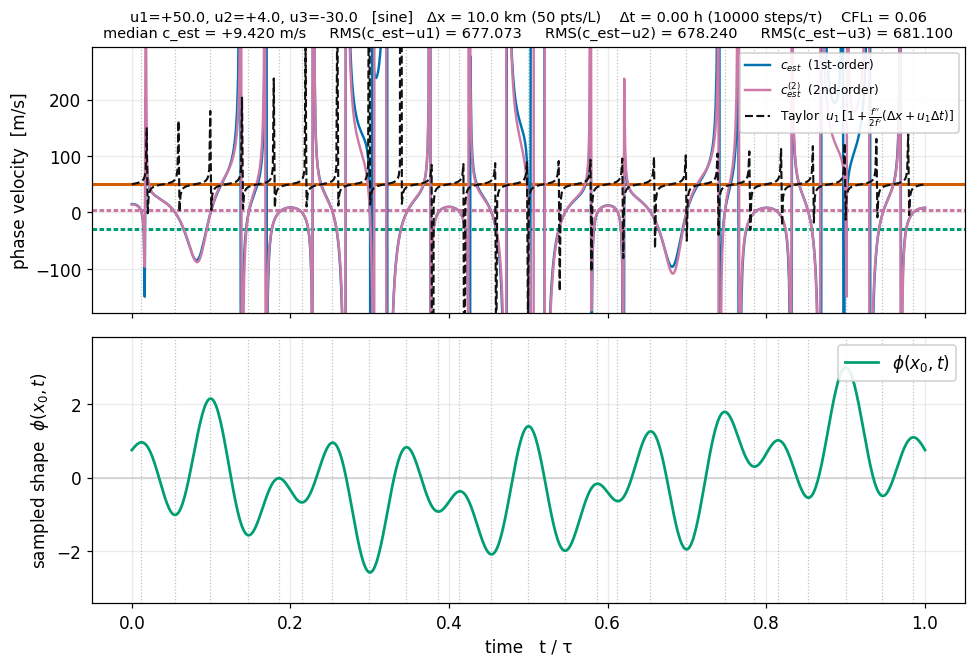

In [143]:
def robust_ylim(y, target, pad=0.30, CUT_defualt = 10):
    """y-limits from the 2..98 percentile band (spikes ignored), including target."""
    y = np.asarray(y); y = y[np.isfinite(y)]
    if y.size == 0:
        return (target - 1.0, target + 1.0)
    lo, hi = np.percentile(y, [CUT_defualt, 100 - CUT_defualt])
    lo, hi = min(lo, target), max(hi, target)
    span = max(hi - lo, 1e-9)
    return (lo - pad*span, hi + pad*span)

def plot_timeseries(dx, dt, x0=None, n_periods=1.0, npts=800, eps_frac=0.0):
    """Top: phase velocity c_est(t) vs theoretical speed(s), with the first-order
    Taylor approximation for the first wave.  Bottom: the wave SHAPE sampled at x0,
    phi(x0,t)=sum_m A_m f_m(x0-u_m t), time-aligned above."""
    if x0 is None:
        x0 = XI_STEEP
    t  = np.linspace(0.0, n_periods*TAU, int(npts))
    rx, c_est = orlanski_estimate(phi, x0, t, dx, dt, eps_frac)
    rx_2nd, c_est_2d = orlanski_estimate_2nd(phi, x0, t, dx, dt, eps_frac)
    phi_x0 = phi(x0, t)                          # sampled shape at x0
    cfl = abs(U_TRUE * dt / dx)
    ppL, ppT = L/dx, TAU/dt
    fin = np.isfinite(c_est); err = c_est[fin] - U_TRUE
    rms = float(np.sqrt(np.mean(err**2))) if err.size else np.nan
    med = float(np.nanmedian(c_est))
    tt  = t / TAU

    # analytic Taylor approximation for the FIRST wave (reference)
    h   = 1e-4 * L
    xi  = x0 - U_TRUE * t
    fp  = lambda z: (f(z + h) - f(z - h)) / (2.0 * h)
    c_ap = U_TRUE * fp(xi + U_TRUE*dt/2.0) / fp(xi - dx/2.0)

    # colour palette for the per-mode speed lines
    speed_colors = [C_TRUE, "#CC79A7", "#009E73", "#F0E442", "#111111"]

    # ---- figure ------------------------------------------------------------
    fig, ax = plt.subplots(2, 1, figsize=(9.0, 6.2), sharex=True)

    # --- top: phase-velocity estimate(s) ------------------------------------
    # one horizontal reference line per wave component
    labels = []
    for k, (name, u, amp) in enumerate(WAVE_SPECS):
        ax[0].axhline(u, color=speed_colors[k % len(speed_colors)], lw=2.0,
                      ls=(0, (1.5, 0.8)) if k > 0 else "-")
        labels.append(f"u{k+1}={u:+.2f}")
    ax[0].plot(tt, c_est,    color=C_EST,     lw=1.6, label=r"$c_{est}$  (1st-order)")
    ax[0].plot(tt, c_est_2d, color="#CC79A7", lw=1.6, label=r"$c_{est}^{(2)}$  (2nd-order)")
    ax[0].plot(tt, c_ap,     color="#111111", lw=1.4, ls="--",
               label=r"Taylor  $u_1\,[1+\frac{f''}{2f'}(\Delta x+u_1\Delta t)]$")

    # y-limit: encompass ALL theoretical speeds + the estimate cloud
    all_speeds = [u for _, u, _ in WAVE_SPECS]
    y_target = np.median(all_speeds)
    ax[0].set_ylim(*robust_ylim(np.concatenate([c_est, c_est_2d]), y_target))
    ax[0].set_ylabel("phase velocity  [m/s]")
    ax[0].legend(loc="upper right", framealpha=0.9, fontsize=8)

    nw = len(WAVE_SPECS)
    speeds_str = ", ".join(f"u{k+1}={u:+.1f}" for k, (_, u, _) in enumerate(WAVE_SPECS))
    title_str = (f"{speeds_str}   [{PROFILE_NAME}]   "
                 f"Δx = {dx/1e3:.1f} km ({ppL:.0f} pts/L)    "
                 f"Δt = {dt/3600:.2f} h ({ppT:.0f} steps/τ)    CFL₁ = {cfl:.2f}\n"
                 f"median c_est = {med:+.3f} m/s")
    if nw > 1:
        for k, (_, u, _) in enumerate(WAVE_SPECS):
            rms_k = float(np.sqrt(np.mean((c_est[fin]-u)**2))) if fin.sum() else np.nan
            title_str += f"     RMS(c_est−u{k+1}) = {rms_k:.3f}"
    else:
        title_str += f"     RMS(c_est−u) = {rms:.3f} m/s"
    ax[0].set_title(title_str, fontsize=9.5)

    # --- bottom: the wave shape sampled at x0 --------------------------------
    ax[1].axhline(0.0, color="0.8", lw=1.0)
    ax[1].plot(tt, phi_x0, color=C_RX, lw=1.8, label=r"$\phi(x_0,t)$")
    span = float(np.nanmax(phi_x0) - np.nanmin(phi_x0)) or 1.0
    ax[1].set_ylim(np.nanmin(phi_x0) - 0.15*span, np.nanmax(phi_x0) + 0.15*span)
    ax[1].set_ylabel(r"sampled shape  $\phi(x_0,t)$")
    ax[1].set_xlabel("time   t / τ")
    ax[1].legend(loc="upper right", framealpha=0.9)

    # correspondence guides: extrema -> Δφ_x->0 -> c_est spikes
    dsh = np.gradient(phi_x0, tt)
    for e in np.where(np.diff(np.sign(dsh)) != 0)[0]:
        for a in ax:
            a.axvline(tt[e], color="0.75", ls=":", lw=0.8, zorder=0)

    fig.tight_layout()
    return fig


_ = plot_timeseries(DX0, DT0); plt.show()


## 6 · Distribution of {est}$  

Two separate figures — 1st-order then 2nd-order.  
Each shows the histogram of {est}$ with vertical lines at the theoretical 
speed(s) from , plus the **RMS error** to each target speed.  
For a single wave the histogram piles up at that speed; for a superposition 
it **spreads between** them.

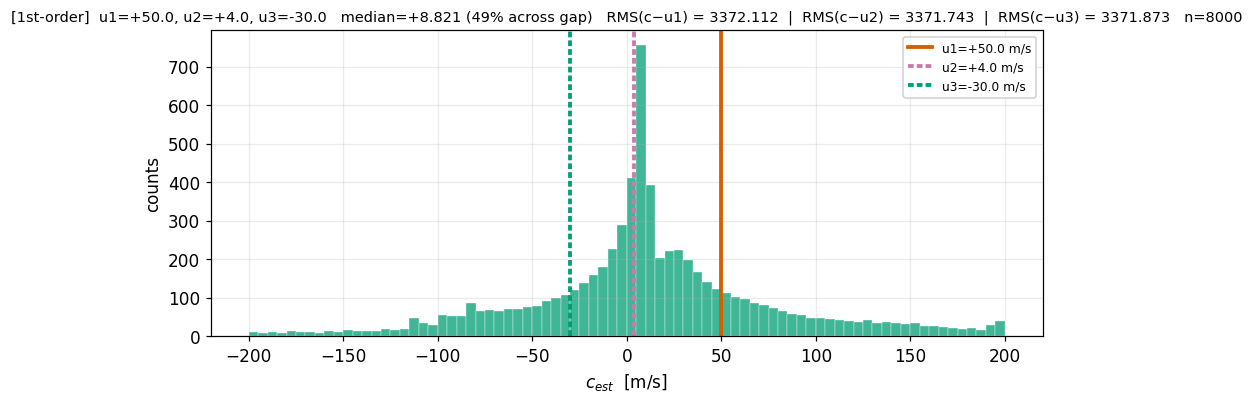

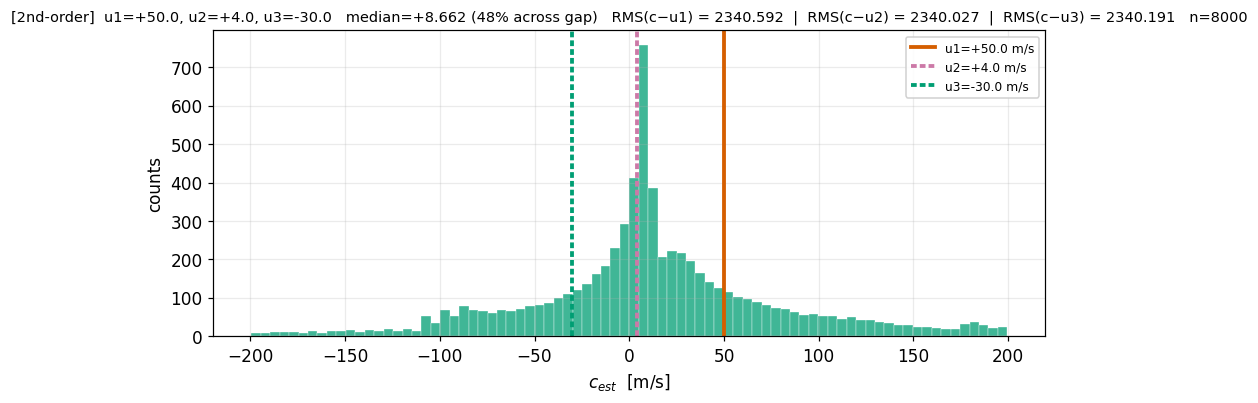

In [144]:
# =====================================================================
# [TW-HIST]  distribution of c_est  vs.  theoretical speed(s)
#            two separate figures: 1st-order, then 2nd-order
# =====================================================================
_, c1 = orlanski_estimate(phi, XI_STEEP, t, dx, dt)
_, c2 = orlanski_estimate_2nd(phi, XI_STEEP, t, dx, dt)

speed_colors = [C_TRUE, "#CC79A7", "#009E73", "#F0E442", "#111111"]
us   = [u for _, u, _ in WAVE_SPECS]
clip = 4 * max(abs(u) for u in us) if us else 20

for c_est, order_label in ((c1, "1st-order"), (c2, "2nd-order")):
    c = c_est[np.isfinite(c_est)]
    med  = float(np.median(c))
    nw   = len(WAVE_SPECS)

    # RMS error(s) -- per theoretical speed
    rms_lines = []
    for k, (name, u, _) in enumerate(WAVE_SPECS):
        err = c - u
        rms = float(np.sqrt(np.mean(err**2)))
        rms_lines.append(f"RMS(c−u{k+1}) = {rms:.3f}")

    fig, ax = plt.subplots(figsize=(8.5, 3.8))

    ax.hist(c[np.abs(c) < clip], bins=80, color=C_RX, alpha=0.75,
            edgecolor="white", lw=0.3)

    for k, (name, u, amp) in enumerate(WAVE_SPECS):
        ax.axvline(u, color=speed_colors[k % len(speed_colors)], lw=2.5,
                   ls=("-" if k == 0 else (0, (1.5, 0.8))),
                   label=f"u{k+1}={u:+.1f} m/s")

    ax.set_xlabel(r"$c_{est}$  [m/s]")
    ax.set_ylabel("counts")

    rms_str = "  |  ".join(rms_lines)
    if nw == 1:
        ax.set_title(f"[{order_label}]  u={WAVE_SPECS[0][1]:+.1f} m/s   "
                     f"median={med:+.3f}   {rms_str}   n={len(c)}",
                     fontsize=10)
    else:
        umin, umax = min(us), max(us)
        gf = (med - umin) / (umax - umin) if umax > umin else 0
        speeds_str = ", ".join(f"u{k+1}={u:+.1f}" for k, (_, u, _) in enumerate(WAVE_SPECS))
        ax.set_title(f"[{order_label}]  {speeds_str}   "
                     f"median={med:+.3f} ({gf:.0%} across gap)   "
                     f"{rms_str}   n={len(c)}",
                     fontsize=9.5)

    ax.legend(loc="upper right", framealpha=0.9, fontsize=8)
    fig.tight_layout()
    plt.show()
